# Plot plate position effects
1. Inner vs outer: observed RMS outer-minus-inner effect vs the label-shuffled null, per compartment.
2. Inner vs outer: per-feature effect vs permutation p-value.
3. DMSO sanity check: pairwise correlations of DMSO wells within column 4, within column 9, and between the two columns, per plate.
Shown as boxplots with every well pair overlaid as a jittered point, once with patient on the x axis and once with well pair on the x axis.

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "arrow", "RColorBrewer")
for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(package, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
        )
    )
}

find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
source(file.path(root_dir, "utils", "r_plot_themes.r"))
source(file.path(root_dir, "utils", "r_plot_funcs.r"))

In [2]:
results_dir <- file.path(root_dir, "5.differential_analysis", "results")
figures_dir <- file.path(root_dir, "5.differential_analysis", "figures")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

position_global_path <- file.path(results_dir, "plate_position_global_test.parquet")
position_null_path <- file.path(results_dir, "plate_position_null.parquet")
position_feature_path <- file.path(results_dir, "plate_position_feature_tests.parquet")
dmso_pair_path <- file.path(results_dir, "dmso_column_pair_correlations.parquet")

null_figure_path <- file.path(figures_dir, "plate_position_inner_vs_outer_null.pdf")
feature_figure_path <- file.path(figures_dir, "plate_position_inner_vs_outer_features.pdf")
dmso_by_patient_figure_path <- file.path(figures_dir, "dmso_column_similarity_by_patient.pdf")
dmso_by_pair_figure_path <- file.path(figures_dir, "dmso_column_similarity_by_well_pair.pdf")

compartment_labels <- c(organoid = "Organoid", single_cell = "Single cell")
pair_type_palette <- c(
    "within column 4" = "#1B9E77",
    "within column 9" = "#7570B3",
    "between columns" = "#D95F02"
)
dodge_width <- 0.7

In [3]:
label_compartment <- function(df) {
    df %>% mutate(compartment = factor(compartment_labels[compartment], levels = compartment_labels))
}
position_global_df <- label_compartment(read_parquet(position_global_path))
position_null_df <- label_compartment(read_parquet(position_null_path))
position_feature_df <- label_compartment(read_parquet(position_feature_path))
dmso_pair_df <- label_compartment(read_parquet(dmso_pair_path)) %>%
    mutate(pair_type = factor(pair_type, levels = names(pair_type_palette)))
position_global_df

compartment,n_groups,n_plates,n_features,observed_rms_effect,null_median_rms_effect,p
<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>
Organoid,95,12,193,0.06905371,0.05555874,0.04969503
Single cell,94,12,397,0.06504021,0.05917576,0.26687331


## Inner vs outer: observed effect vs null

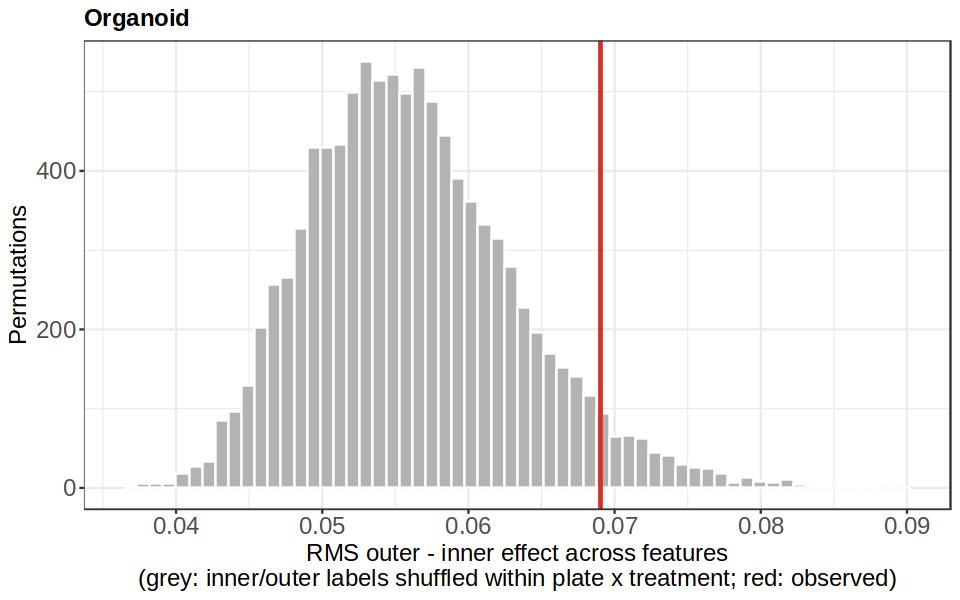

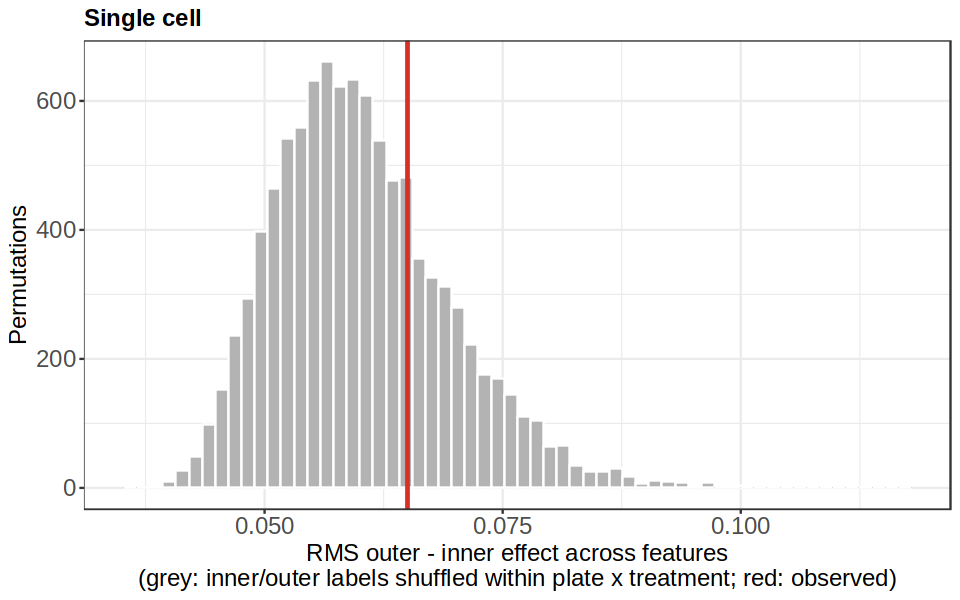

In [4]:
options(repr.plot.width = 8, repr.plot.height = 5)
null_plots <- lapply(levels(position_null_df$compartment), function(compartment_name) {
    (
        ggplot(position_null_df %>% filter(compartment == compartment_name), aes(x = null_rms_effect))
        + geom_histogram(bins = 60, fill = "grey70", color = "white")
        + geom_vline(
            data = position_global_df %>% filter(compartment == compartment_name),
            aes(xintercept = observed_rms_effect),
            color = "#d73027",
            linewidth = 1
        )
        + labs(
            title = compartment_name,
            x = "RMS outer - inner effect across features\n(grey: inner/outer labels shuffled within plate x treatment; red: observed)",
            y = "Permutations"
        )
        + theme_manuscript(base_size = 14)
    )
})
save_plots_pdf(null_plots, null_figure_path, width = 8, height = 5)
for (null_plot in null_plots) print(null_plot)

## Inner vs outer: per-feature effects

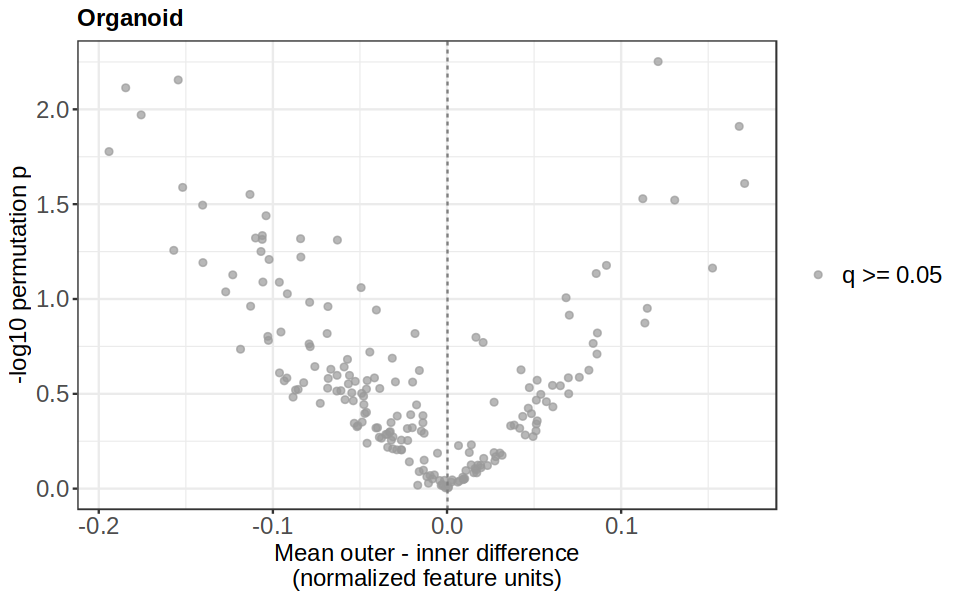

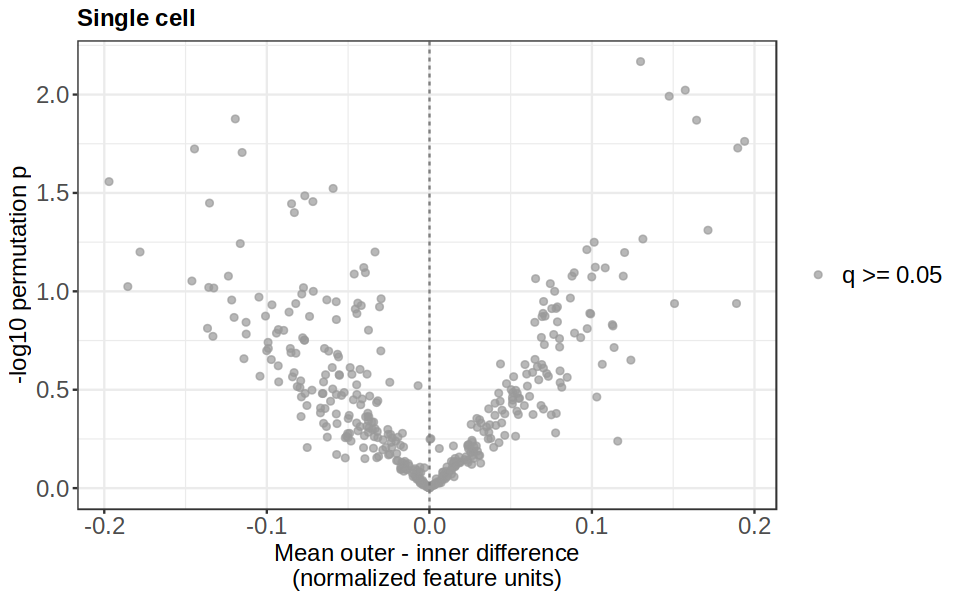

In [5]:
options(repr.plot.width = 8, repr.plot.height = 5)
feature_plots <- lapply(levels(position_feature_df$compartment), function(compartment_name) {
    (
        ggplot(
            position_feature_df %>% filter(compartment == compartment_name),
            aes(x = outer_minus_inner, y = -log10(p), color = q < 0.05)
        )
        + geom_point(size = 1.5, alpha = 0.7)
        + geom_vline(xintercept = 0, linetype = "dashed", color = "grey50")
        + scale_color_manual(values = c("FALSE" = "grey60", "TRUE" = "#d73027"), labels = c("FALSE" = "q >= 0.05", "TRUE" = "q < 0.05"))
        + labs(
            title = compartment_name,
            x = "Mean outer - inner difference\n(normalized feature units)",
            y = "-log10 permutation p",
            color = NULL
        )
        + theme_manuscript(base_size = 14)
    )
})
save_plots_pdf(feature_plots, feature_figure_path, width = 8, height = 5)
for (feature_plot in feature_plots) print(feature_plot)

## DMSO column 4 vs column 9
Boxes summarize the pairwise correlations; each well pair is one jittered point.

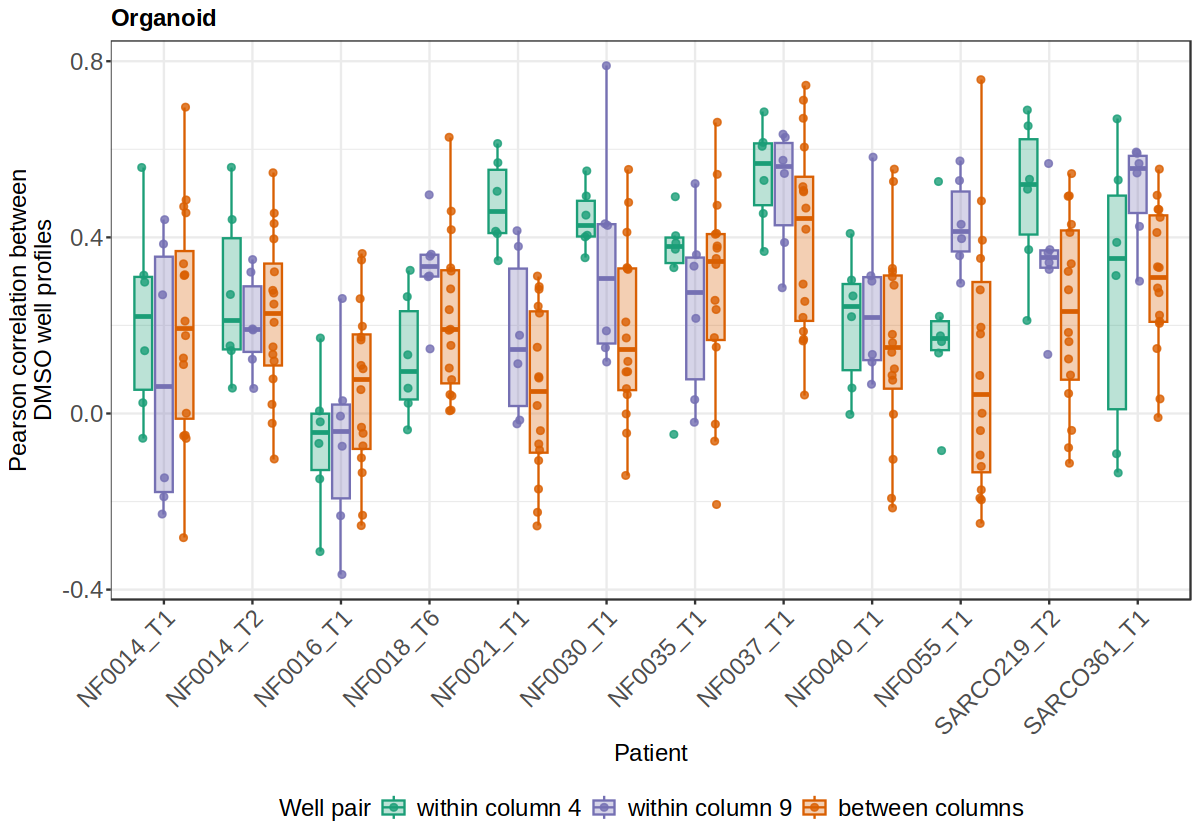

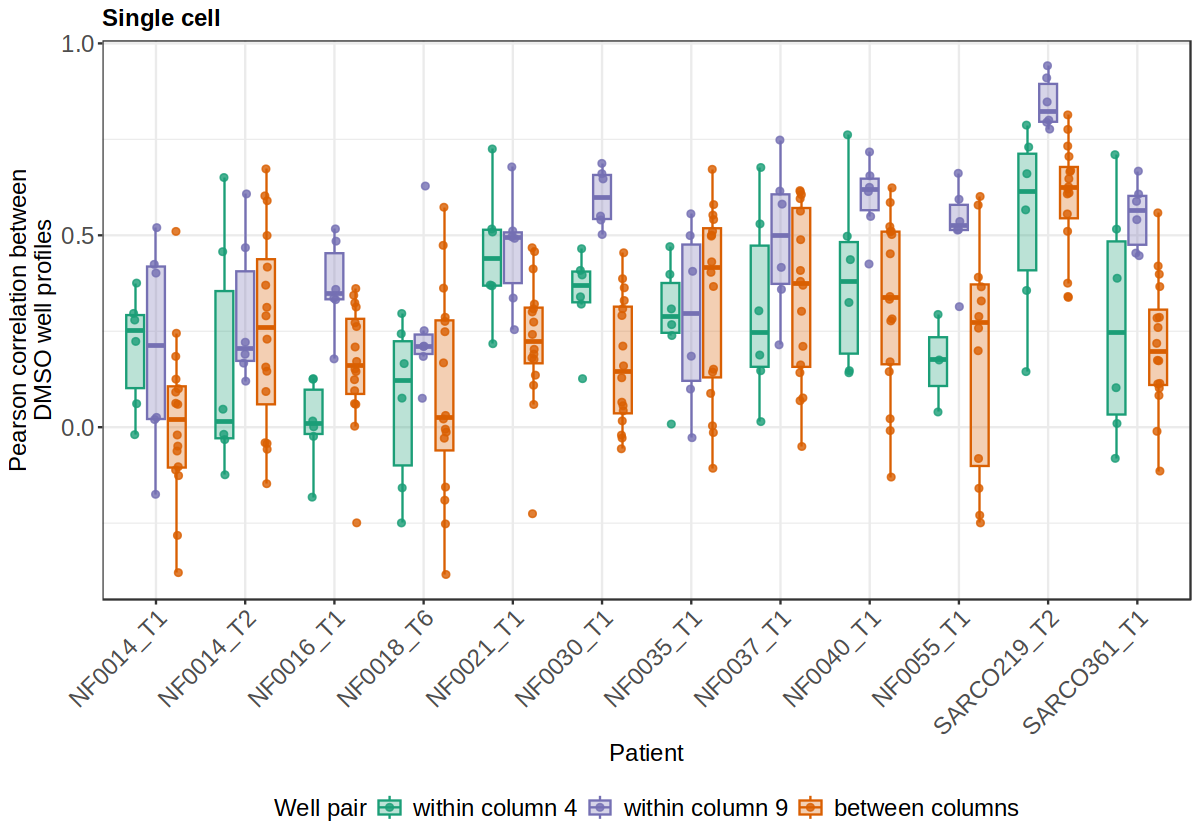

In [6]:
stopifnot(all(dmso_pair_df$Metadata_Biology_PatientTumor %in% names(patient_palette)))
dmso_pair_df <- dmso_pair_df %>%
    mutate(
        Metadata_Biology_PatientTumor = factor(
            Metadata_Biology_PatientTumor, levels = names(patient_palette)
        )
    )

options(repr.plot.width = 10, repr.plot.height = 7)
dmso_by_patient_plots <- lapply(levels(dmso_pair_df$compartment), function(compartment_name) {
    (
        ggplot(
            dmso_pair_df %>% filter(compartment == compartment_name),
            aes(x = Metadata_Biology_PatientTumor, y = correlation, color = pair_type, fill = pair_type)
        )
        + geom_boxplot(
            position = position_dodge(width = dodge_width),
            width = 0.6,
            outlier.shape = NA,
            alpha = 0.3
        )
        + geom_point(
            position = position_jitterdodge(jitter.width = 0.1, dodge.width = dodge_width, seed = 0),
            size = 1.5,
            alpha = 0.8
        )
        + scale_color_manual(values = pair_type_palette)
        + scale_fill_manual(values = pair_type_palette)
        + labs(
            title = compartment_name,
            x = "Patient",
            y = "Pearson correlation between\nDMSO well profiles",
            color = "Well pair",
            fill = "Well pair"
        )
        + theme_manuscript(base_size = 14, x_text = "angled")
        + theme(legend.position = "bottom")
    )
})
save_plots_pdf(dmso_by_patient_plots, dmso_by_patient_figure_path, width = 10, height = 7)
for (dmso_plot in dmso_by_patient_plots) print(dmso_plot)

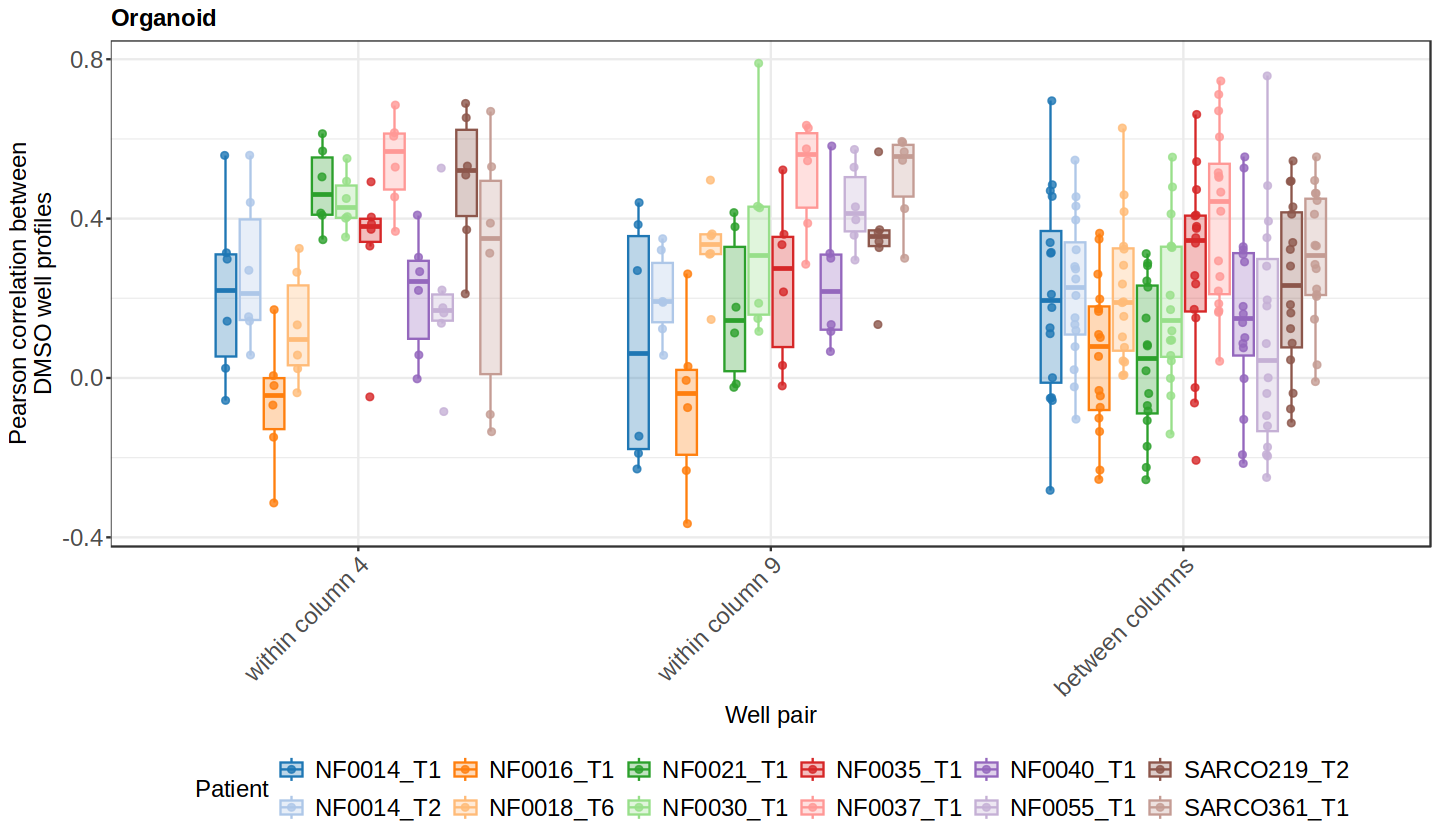

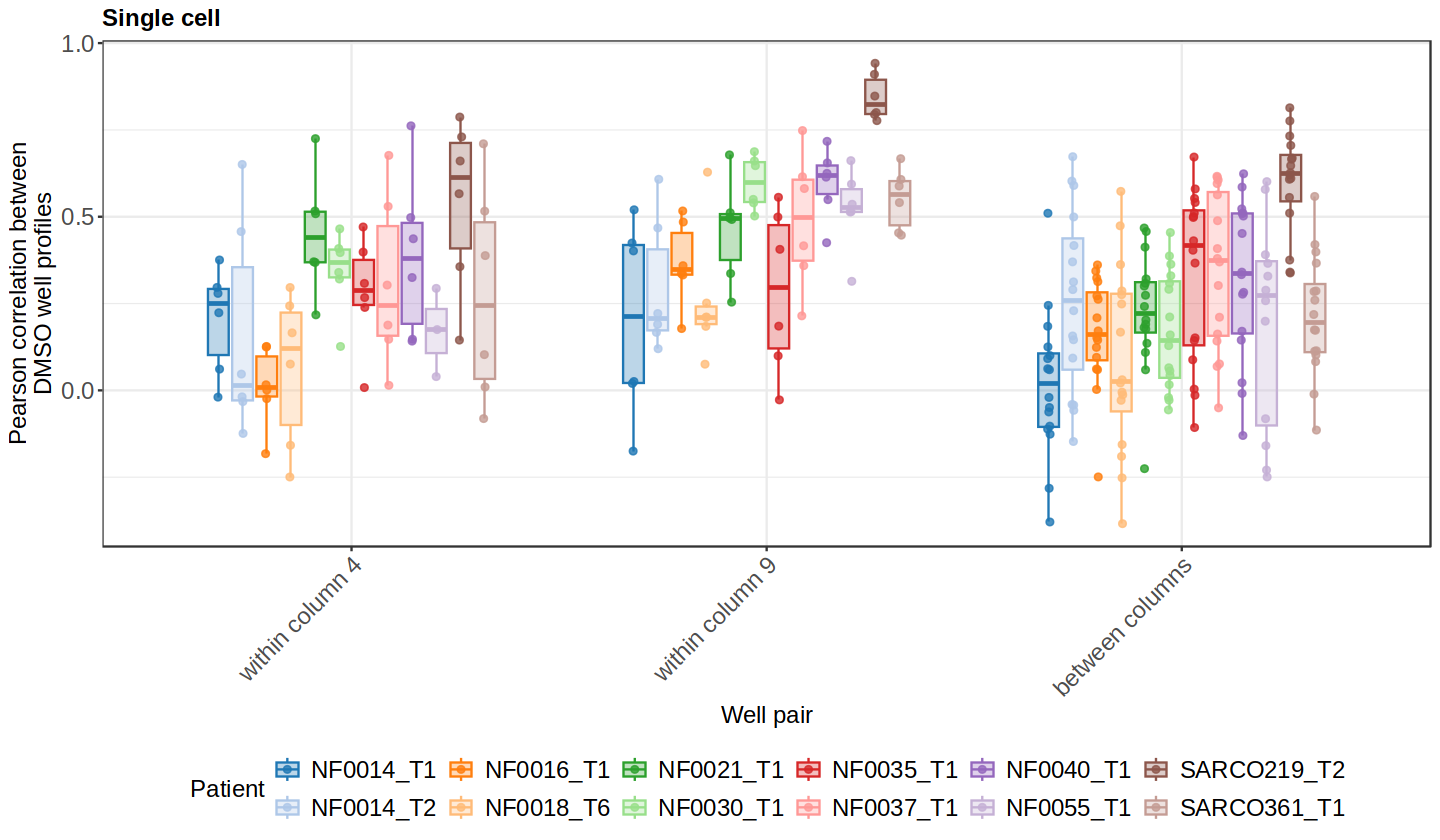

In [7]:
options(repr.plot.width = 12, repr.plot.height = 7)
dmso_by_pair_plots <- lapply(levels(dmso_pair_df$compartment), function(compartment_name) {
    (
        ggplot(
            dmso_pair_df %>% filter(compartment == compartment_name),
            aes(x = pair_type, y = correlation, color = Metadata_Biology_PatientTumor, fill = Metadata_Biology_PatientTumor)
        )
        + geom_boxplot(
            position = position_dodge(width = dodge_width),
            width = 0.6,
            outlier.shape = NA,
            alpha = 0.3
        )
        + geom_point(
            position = position_jitterdodge(jitter.width = 0.05, dodge.width = dodge_width, seed = 0),
            size = 1.5,
            alpha = 0.8
        )
        + scale_color_manual(values = patient_palette)
        + scale_fill_manual(values = patient_palette)
        + labs(
            title = compartment_name,
            x = "Well pair",
            y = "Pearson correlation between\nDMSO well profiles",
            color = "Patient",
            fill = "Patient"
        )
        + theme_manuscript(base_size = 14, x_text = "angled")
        + theme(legend.position = "bottom")
        + guides(color = guide_legend(nrow = 2), fill = guide_legend(nrow = 2))
    )
})
save_plots_pdf(dmso_by_pair_plots, dmso_by_pair_figure_path, width = 12, height = 7)
for (dmso_plot in dmso_by_pair_plots) print(dmso_plot)